# Configurações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
home = os.getcwd()
diretorio_projeto = home
os.chdir(diretorio_projeto)

if diretorio_projeto not in sys.path:
    sys.path.append(diretorio_projeto)

from visualisation import plotar_metricas_cv, plotar_loss_cv, imprimir_metricas_finais


In [ ]:

def compilar_estatisticas_cv(caminho_raiz, nome_logger="cv_resultados", num_folds=10):
    lista_dfs = []

    for i in range(1, num_folds + 1):
        caminho_csv = f"{caminho_raiz}/{nome_logger}/fold_{i}/metrics.csv"

        if os.path.exists(caminho_csv):
            df_fold = pd.read_csv(caminho_csv)
            df_fold_limpo = df_fold.groupby('epoch').mean().reset_index()
            lista_dfs.append(df_fold_limpo)
        else:
            print(f"Aviso: Log do fold_{i} não encontrado.")

    if not lista_dfs:
        raise ValueError("Nenhum arquivo de log encontrado.")

    df_completo = pd.concat(lista_dfs)

    df_stats = df_completo.groupby('epoch').agg(['mean', 'std'])
    df_stats.columns = ['_'.join(col).strip() for col in df_stats.columns.values]
    df_stats = df_stats.reset_index()

    return df_stats


In [ ]:

diretorio_logs = f"{diretorio_projeto}/logs"

# Análise do modelo

# Resultados



## Baseline


In [ ]:
df_resultados= compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados")

In [ ]:
print("Resultados do modelo baseline:")
imprimir_metricas_finais(df_resultados)


Resultados do modelo baseline:
Relatório - 10 Folds
AUROC            : 0.9210 ± 0.0047
F1-Score         : 0.1333 ± 0.0350


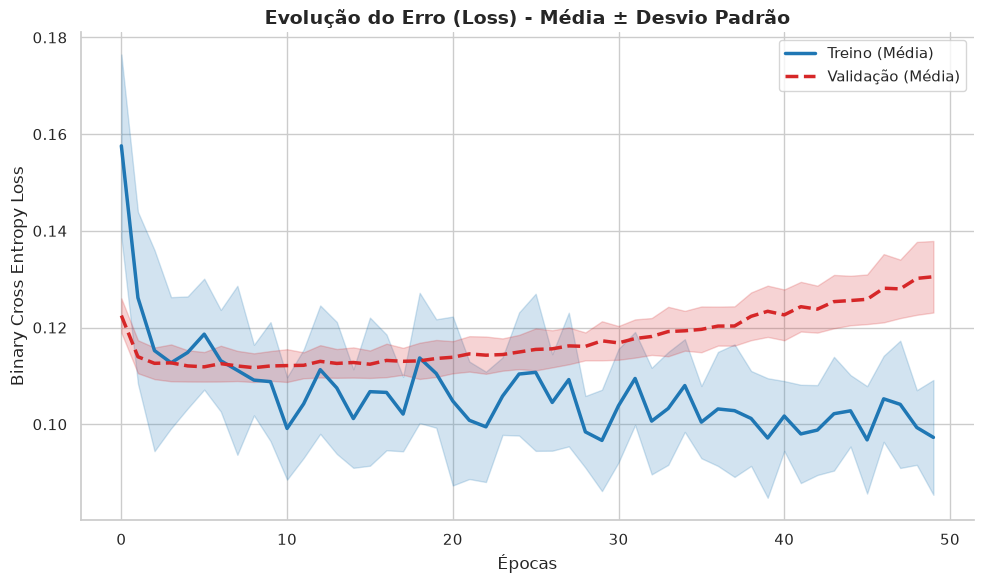

In [6]:
plotar_loss_cv(df_resultados)

Essas mudanças abruptas e loss alta podem indicar que nossa learning rate está muito alta, alem disso podemos ver que a partir da epoca 27 o modelo começa a sofrer um overfitting, com a loss do treino descendo enquanto a loss de validação aumenta.

Alem disso, para a v2 vamos adicionar class weighting para tentar melhorar o f1 score.

## modelo V2

In [ ]:
df_resultados_v2 = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados_v2")

In [8]:
print("\nResultados do modelo v2:")
imprimir_metricas_finais(df_resultados_v2)



Resultados do modelo v2:
Relatório - 10 Folds
AUROC            : 0.9273 ± 0.0038
F1-Score         : 0.3226 ± 0.0139


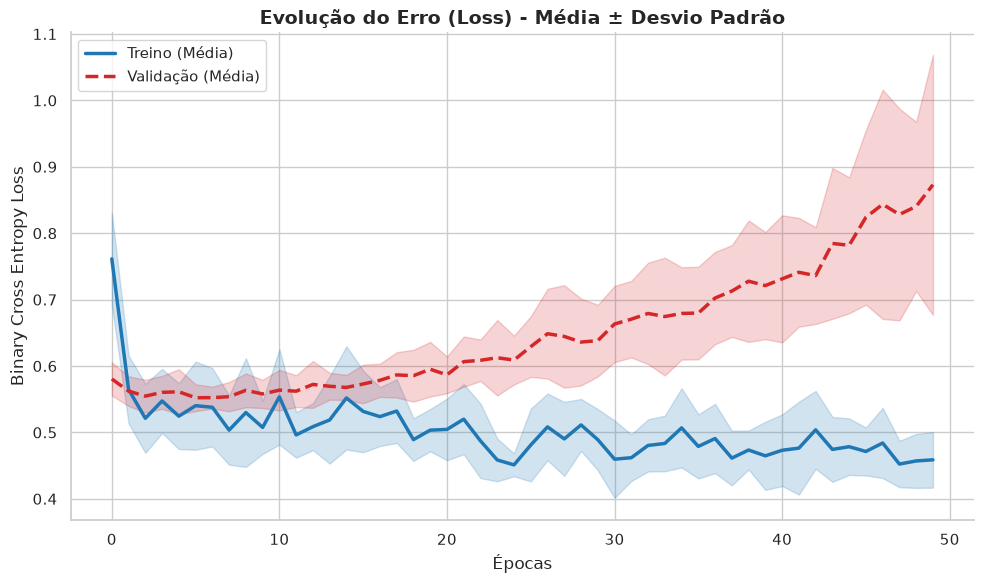

In [9]:
plotar_loss_cv(df_resultados_v2)

Parece que as mudanças não ajudaram muito, eu vou avaliar algumas arquiteturas com um breve sweep e adicionar uma regularização.

In [ ]:

diretorio_output = f"{diretorio_projeto}/output"
sweep_df = pd.read_csv(f"{diretorio_output}/capacity_sweep_resultados.csv")

In [11]:
sweep_df = sweep_df.sort_values(by='val_loss', ascending=True)
sweep_df

,n_hidden,n_neurons,total_params,trainable_params,val_loss,val_auroc,val_f1
0,1,32,2273,2273,0.530682,0.936269,0.331990
4,3,16,1425,1425,0.532419,0.935234,0.328335
1,2,16,1153,1153,0.534408,0.935449,0.326954
2,3,32,4385,4385,0.535186,0.935348,0.326275
7,4,16,1697,1697,0.541165,0.933809,0.317757
9,1,16,881,881,0.541865,0.933670,0.327156
3,0,32,1217,1217,0.543083,0.935310,0.341995
5,0,64,2433,2433,0.543759,0.934906,0.338333
8,0,128,4865,4865,0.547006,0.933703,0.339781
10,2,32,3329,3329,0.548796,0.933193,0.330379


Até um momento estavamos utilizando n_hidden = 3 e n_neurons = 32, vamos reduzir o número de camadas ocultas e utilizar dropout para proxima iteração.

## Modelo V3



Resultados do modelo v3:
Relatório - 10 Folds
AUROC            : 0.9355 ± 0.0044
F1-Score         : 0.3287 ± 0.0110


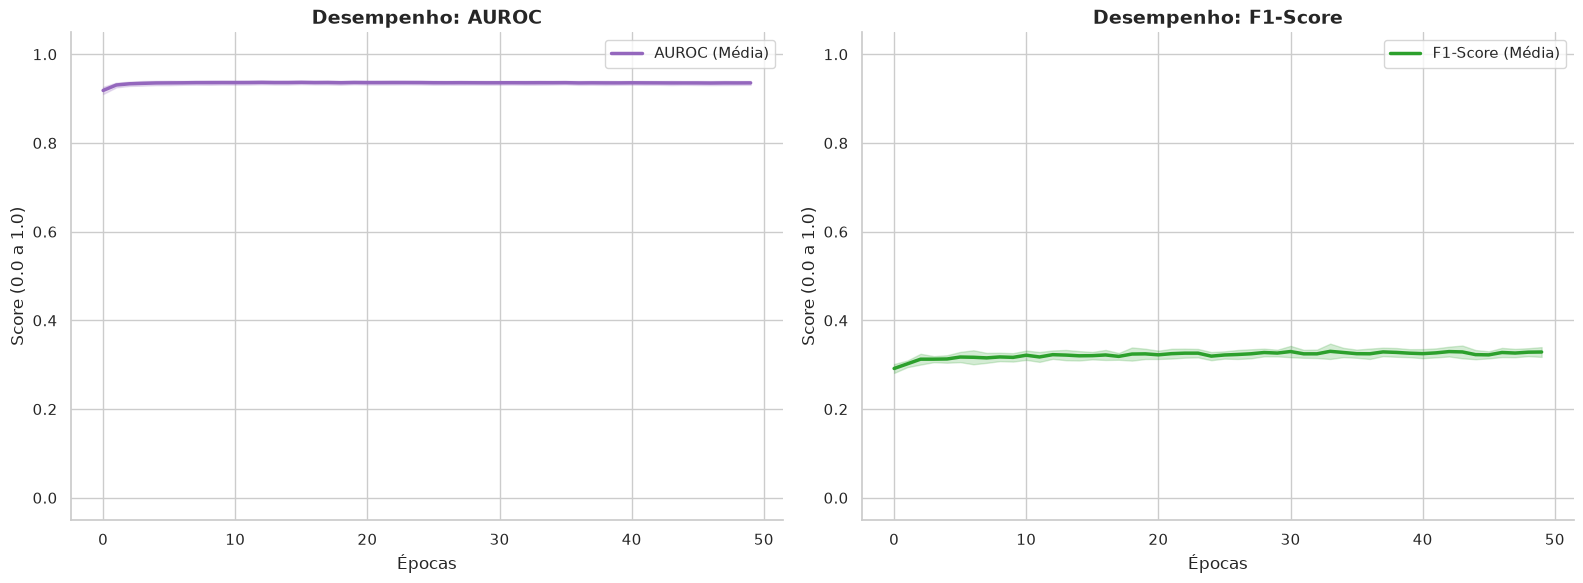

In [12]:
df_resultados_v3 = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados_v3")
print("\nResultados do modelo v3:")
imprimir_metricas_finais(df_resultados_v3)
plotar_metricas_cv(df_resultados_v3)

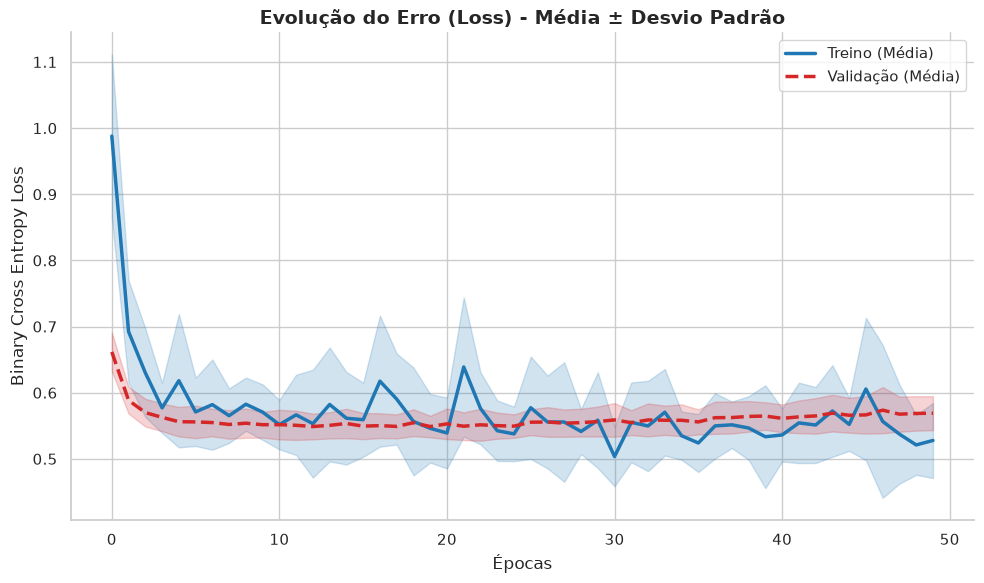

In [13]:
plotar_loss_cv(df_resultados_v3)

Agora que melhoramos um pouco o overfitting, vamos tentar melhorar o f1 treinando o limiar de decisão.


Alem disso vou começar a monitorar outras métricas

In [14]:
sweep_df = pd.read_csv(f"{diretorio_output}/pos_weight_sweep_resultados.csv")
sweep_df = sweep_df.sort_values(by='val_loss', ascending=True)
sweep_df

,pos_weight,dropout,val_loss,val_auroc,val_f1
2,5.0,0.5,0.282148,0.936061,0.426396
12,5.0,0.3,0.290456,0.933302,0.407876
13,5.0,0.1,0.290894,0.932781,0.410397
1,10.0,0.5,0.393075,0.937101,0.372719
11,10.0,0.1,0.405969,0.933325,0.379098
10,10.0,0.3,0.408182,0.933468,0.359023
0,15.0,0.5,0.470286,0.937586,0.334707
7,15.0,0.3,0.484235,0.934968,0.352423
9,15.0,0.1,0.487737,0.934097,0.341297
3,20.0,0.3,0.546876,0.935381,0.313124


Nosso F1 ainda está ruim, vamos procurar um peso melhor para a a classe positiva. Vou aproveitar para testar se o dropout está em um valor bom.

## Modelo V4


In [ ]:
df_resultados_v4 = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados_v4")

In [16]:
print("\nResultados do modelo v4:")
imprimir_metricas_finais(df_resultados_v4)


Resultados do modelo v4:
Relatório - 10 Folds
AUROC            : 0.9359 ± 0.0041
F1-Score         : 0.4062 ± 0.0138


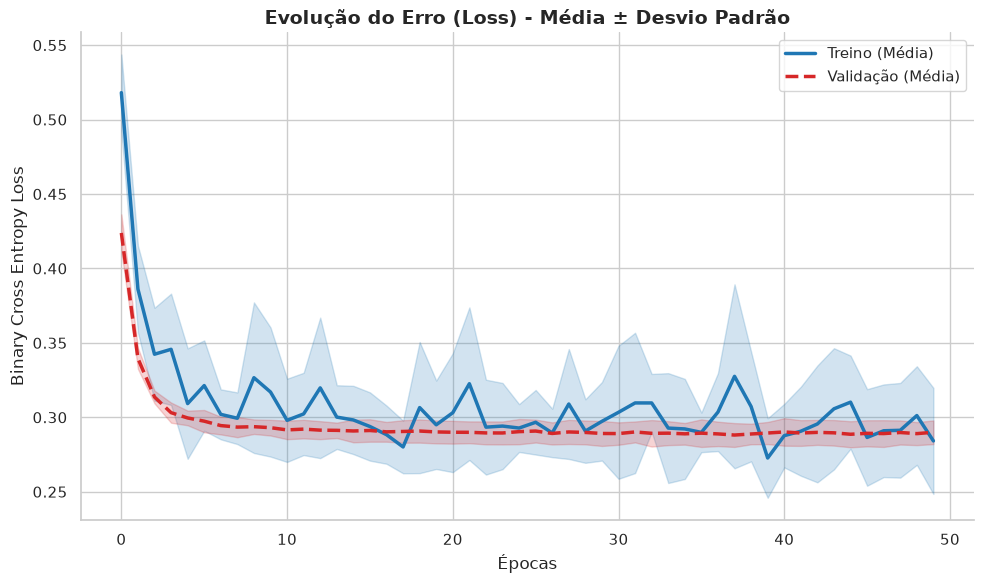

In [17]:
plotar_loss_cv(df_resultados_v4)

## Modelo V5

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

def imprimir_metricas_finais_cv(log_dir="logs/cv_resultados_v5/folds"):
    arquivos = list(Path(log_dir).rglob("metrics.csv"))

    if not arquivos:
        raise FileNotFoundError(f"Nenhum metrics.csv encontrado em: {log_dir}")

    resultados_folds = []

    for arquivo in arquivos:
        df = pd.read_csv(arquivo)
        df = df.dropna(subset=['epoch'])
        df['epoch'] = df['epoch'].astype(int)

        # Consolida as linhas de treino e validação da mesma época
        df_epocas = df.groupby('epoch', as_index=False).last()

        ultima_epoca = df_epocas['epoch'].max()
        resultado_final = df_epocas[df_epocas['epoch'] == ultima_epoca].iloc[0].to_dict()
        resultado_final['epochs'] = ultima_epoca + 1
        resultado_final['fold'] = arquivo.parent.name
        resultados_folds.append(resultado_final)

    df_resultados = pd.DataFrame(resultados_folds)

    metricas = {
        'val_auroc': 'AUROC',
        'val_average_precision': 'Average Precision',
        'val_f1_threshold_05': 'F1-Score (Threshold 0.5)',
        'val_f1_optimized': 'F1-Score Otimizado',
        'val_precision_optimized': 'Precision',
        'val_recall_optimized': 'Recall',
        'val_specificity_optimized': 'Specificity',
        'val_accuracy_optimized': 'Accuracy',
        'val_balanced_accuracy_optimized': 'Balanced Accuracy',
        'val_best_threshold': 'Melhor Threshold',
        'epochs': 'Épocas'
    }

    print("="*70)
    print(f"Resultados finais - {len(df_resultados)} Folds")
    print("="*70)

    metricas_ausentes = []

    for coluna, nome in metricas.items():
        if coluna not in df_resultados.columns:
            metricas_ausentes.append(coluna)
            continue

        valores = pd.to_numeric(df_resultados[coluna], errors='coerce').dropna()

        if valores.empty:
            metricas_ausentes.append(coluna)
            continue

        desvio = valores.std(ddof=1) if len(valores) > 1 else 0.0

        if coluna == 'epochs':
            print(f"{nome:<32}: {valores.mean():.1f} ± {desvio:.1f}")
        else:
            print(f"{nome:<32}: {valores.mean():.4f} ± {desvio:.4f}")

    print("="*70)

    if metricas_ausentes:
        print("\nMétricas não encontradas nos arquivos:")
        print(", ".join(metricas_ausentes))

    return df_resultados

In [21]:
df_resultados_v5 = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados_v5_final")

In [23]:
print("\nResultados do modelo v5:")
imprimir_metricas_finais_cv("logs/cv_resultados_v5_final")


Resultados do modelo v5:
Resultados finais - 10 Folds
AUROC                           : 0.9361 ± 0.0046
Average Precision               : 0.3346 ± 0.0211
F1-Score (Threshold 0.5)        : 0.4057 ± 0.0152
F1-Score Otimizado              : 0.4365 ± 0.0138
Precision                       : 0.3376 ± 0.0226
Recall                          : 0.6282 ± 0.0729
Specificity                     : 0.9417 ± 0.0112
Accuracy                        : 0.9277 ± 0.0077
Balanced Accuracy               : 0.7849 ± 0.0313
Melhor Threshold                : 0.6035 ± 0.0345
Épocas                          : 28.3 ± 7.0


,epoch,step,train_loss,val_accuracy_optimized,val_auroc,val_average_precision,val_balanced_accuracy_optimized,val_best_threshold,val_f1_optimized,val_f1_threshold_05,val_false_negatives,val_false_positives,val_loss,val_precision_optimized,val_recall_optimized,val_specificity_optimized,val_true_negatives,val_true_positives,epochs,fold
0,32.0,5807.0,0.290251,0.9212,0.935968,0.311378,0.792037,0.590,0.423977,0.406032,78.0,316.0,0.282779,0.314534,0.650224,0.933850,4461.0,145.0,33,fold_5
1,28.0,5103.0,0.291474,0.9318,0.933713,0.315306,0.769797,0.625,0.436364,0.395006,91.0,250.0,0.291940,0.345550,0.591928,0.947666,4527.0,132.0,29,fold_7
2,31.0,5631.0,0.294072,0.9214,0.945051,0.375394,0.837029,0.535,0.457931,0.438961,57.0,336.0,0.266701,0.330677,0.744395,0.929663,4441.0,166.0,32,fold_6
3,27.0,4927.0,0.294139,0.9170,0.938647,0.351689,0.824039,0.575,0.436906,0.410611,62.0,353.0,0.283512,0.313230,0.721973,0.926104,4424.0,161.0,28,fold_2
4,25.0,4575.0,0.292931,0.9210,0.935698,0.320113,0.804757,0.590,0.433286,0.411281,72.0,323.0,0.284150,0.318565,0.677130,0.932384,4454.0,151.0,26,fold_1
5,17.0,3167.0,0.291242,0.9272,0.929863,0.322273,0.770422,0.620,0.424051,0.399527,90.0,274.0,0.298728,0.328431,0.598214,0.942630,4502.0,134.0,18,fold_9
6,19.0,3519.0,0.295353,0.9284,0.929683,0.322201,0.770155,0.595,0.426282,0.389642,90.0,268.0,0.301350,0.331671,0.596413,0.943898,4509.0,133.0,20,fold_4
7,28.0,5103.0,0.290879,0.9404,0.937122,0.327290,0.727273,0.655,0.424710,0.395928,113.0,185.0,0.282596,0.372881,0.493274,0.961273,4592.0,110.0,29,fold_3
8,24.0,4399.0,0.294609,0.9378,0.940354,0.357591,0.775971,0.640,0.462867,0.419355,90.0,221.0,0.281293,0.377465,0.598214,0.953727,4555.0,134.0,25,fold_10
9,42.0,7567.0,0.289517,0.9304,0.934804,0.342358,0.777614,0.610,0.438710,0.390465,87.0,261.0,0.291388,0.342569,0.609865,0.945363,4516.0,136.0,43,fold_8


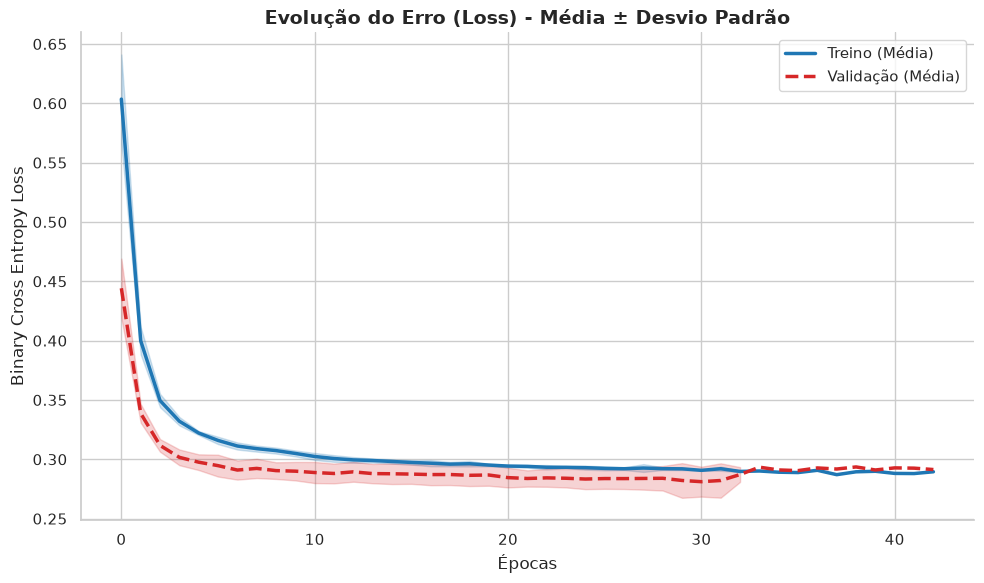

In [24]:
plotar_loss_cv(df_resultados_v5)

In [25]:
def carregar_dados():
    games = pd.read_csv("data/games.csv")
    trends = pd.read_csv("data/yearly_trends.csv")
    return games, trends

In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import pytorch_lightning as L
from sklearn.model_selection import StratifiedKFold
from models import ClassificadorV5,  GOTYModelV4
from data_handler import GOTYDataModule
import config as cfg
from models import ClassificadorV5, GOTYModelV4
RUN_NAME = "cv_resultados_v5_final"
def gerar_previsoes_oof(run_name=RUN_NAME):
    games, trends = carregar_dados()

    X_baseline = games.drop(columns=cfg.COLUNAS_DROP, errors='ignore')
    y = games['goty_nominated'].reset_index(drop=True)

    oof_probabilities = np.full(len(y), np.nan, dtype=np.float32)
    oof_folds = np.zeros(len(y), dtype=np.int32)

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_baseline, y)):
        print(f"Gerando previsões OOF do fold {fold + 1}/10")

        data_module = GOTYDataModule(
            X=X_baseline,
            y=y,
            trends_df=trends,
            train_idx=train_idx,
            val_idx=val_idx,
            batch_size=cfg.BATCH_SIZE
        )

        data_module.setup()

        modelo_base = ClassificadorV5(
            input_size=data_module.input_size,
            n_neurons=cfg.N_NEURONS,
            n_hidden=cfg.N_HIDDEN,
            dropout_rate=0.5
        )

        checkpoint_dir = Path("logs") / run_name / f"fold_{fold + 1}" / "checkpoints"
        checkpoints = list(checkpoint_dir.glob("*.ckpt"))

        if len(checkpoints) != 1:
            raise ValueError(f"Esperado 1 checkpoint em {checkpoint_dir}, encontrados: {len(checkpoints)}")

        # Mudança: carrega o melhor checkpoint daquele fold
        l_model = GOTYModelV4.load_from_checkpoint(
            str(checkpoints[0]),
            model=modelo_base,
            learning_rate=cfg.LR,
            pos_weight_val=5,
            map_location=device
        )

        l_model.to(device)
        l_model.eval()

        fold_probabilities = []
        fold_targets = []

        with torch.no_grad():
            for x_batch, y_batch in data_module.val_dataloader():
                x_batch = x_batch.to(device)
                logits = l_model(x_batch).squeeze(-1)
                probabilities = torch.sigmoid(logits)

                fold_probabilities.append(probabilities.cpu().numpy())
                fold_targets.append(y_batch.cpu().numpy())

        fold_probabilities = np.concatenate(fold_probabilities)
        fold_targets = np.concatenate(fold_targets).astype(int)
        expected_targets = y.iloc[val_idx].to_numpy().astype(int)

        if not np.array_equal(fold_targets, expected_targets):
            raise ValueError("A ordem do val_dataloader não corresponde a val_idx. Verifique se shuffle=False.")

        oof_probabilities[val_idx] = fold_probabilities
        oof_folds[val_idx] = fold + 1

    if np.isnan(oof_probabilities).any():
        raise ValueError("Algumas amostras não receberam previsão OOF.")

    df_oof = pd.DataFrame({
        'index': np.arange(len(y)),
        'fold': oof_folds,
        'y_true': y.to_numpy().astype(int),
        'y_probability': oof_probabilities
    })

    output_path = Path("logs") / run_name / "oof_predictions.csv"
    df_oof.to_csv(output_path, index=False)

    print(f"\nPrevisões salvas em: {output_path}")
    return df_oof

In [28]:
df_oof = gerar_previsoes_oof()

Gerando previsões OOF do fold 1/10
Gerando previsões OOF do fold 2/10
Gerando previsões OOF do fold 3/10
Gerando previsões OOF do fold 4/10
Gerando previsões OOF do fold 5/10
Gerando previsões OOF do fold 6/10
Gerando previsões OOF do fold 7/10
Gerando previsões OOF do fold 8/10
Gerando previsões OOF do fold 9/10
Gerando previsões OOF do fold 10/10

Previsões salvas em: logs/cv_resultados_v5_final/oof_predictions.csv


In [29]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score
)

def analisar_threshold_oof(df_oof):
    y_true = df_oof['y_true'].to_numpy()
    y_probability = df_oof['y_probability'].to_numpy()

    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, y_probability)
    f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / np.maximum(precision_curve[:-1] + recall_curve[:-1], 1e-8)

    best_index = np.argmax(f1_curve)
    best_threshold = thresholds[best_index]

    y_pred_05 = (y_probability >= 0.5).astype(int)
    y_pred = (y_probability >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    print("="*65)
    print("Resultados Out-of-Fold - 10 Folds")
    print("="*65)
    print(f"AUROC                         : {roc_auc_score(y_true, y_probability):.4f}")
    print(f"Average Precision             : {average_precision_score(y_true, y_probability):.4f}")
    print(f"F1-Score (Threshold 0.5)      : {f1_score(y_true, y_pred_05):.4f}")
    print(f"F1-Score Otimizado            : {f1_score(y_true, y_pred):.4f}")
    print(f"Precision                     : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall                        : {recall_score(y_true, y_pred):.4f}")
    print(f"Specificity                   : {specificity:.4f}")
    print(f"Accuracy                      : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Balanced Accuracy             : {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"Melhor Threshold              : {best_threshold:.4f}")
    print("="*65)

    return best_threshold, y_pred

In [30]:
best_threshold, y_pred_oof = analisar_threshold_oof(df_oof)

Resultados Out-of-Fold - 10 Folds
AUROC                         : 0.9368
Average Precision             : 0.3283
F1-Score (Threshold 0.5)      : 0.4069
F1-Score Otimizado            : 0.4307
Precision                     : 0.3384
Recall                        : 0.5923
Specificity                   : 0.9459
Accuracy                      : 0.9301
Balanced Accuracy             : 0.7691
Melhor Threshold              : 0.6115


In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plotar_matriz_confusao_oof(df_oof, threshold, normalizada=False):
    y_true = df_oof['y_true'].to_numpy()
    y_probability = df_oof['y_probability'].to_numpy()
    y_pred = (y_probability >= threshold).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=['Não indicado', 'Indicado'],
        normalize='true' if normalizada else None,
        values_format='.2%' if normalizada else 'd'
    )

    titulo = 'Matriz de Confusão' if normalizada else 'Matriz de Confusão - Previsões OOF'
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

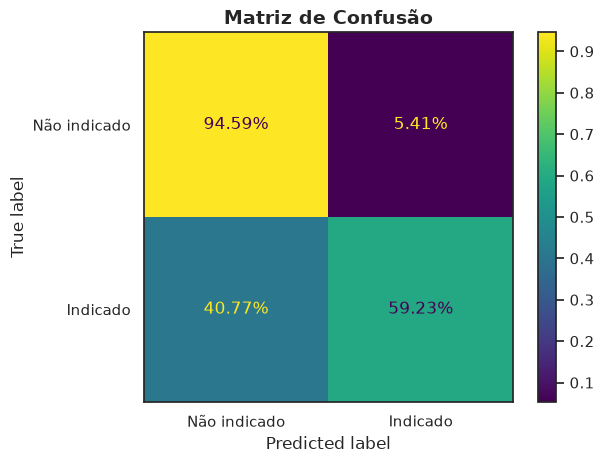

In [36]:
sns.set_theme(style="white")
plotar_matriz_confusao_oof(df_oof, best_threshold, normalizada=True)

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

def plotar_curva_roc_oof(df_oof):
    y_true = df_oof['y_true'].to_numpy()
    y_probability = df_oof['y_probability'].to_numpy()

    fpr, tpr, _ = roc_curve(y_true, y_probability)
    auroc = roc_auc_score(y_true, y_probability)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2.5, label=f'Modelo V5 (AUROC = {auroc:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Classificador aleatório')

    plt.title('Curva ROC - Previsões Out-of-Fold', fontsize=14, fontweight='bold')
    plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
    plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

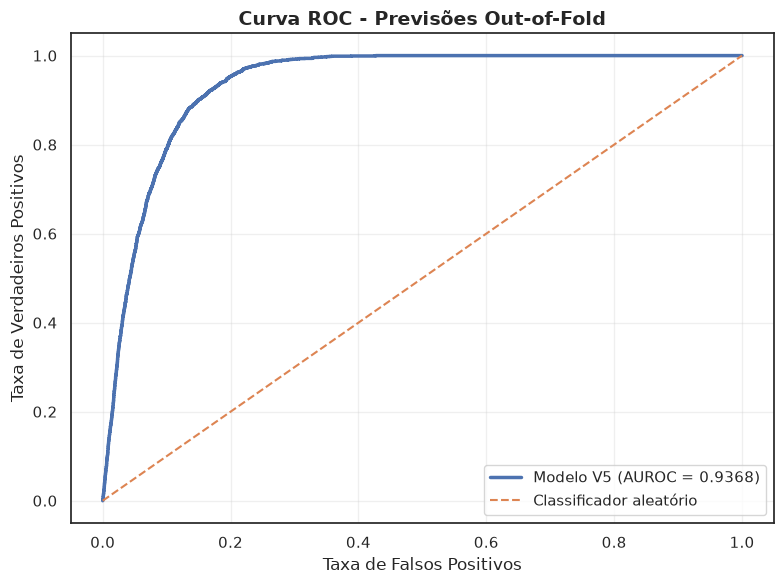

In [40]:
plotar_curva_roc_oof(df_oof)

## UPsample e downsample


In [44]:
df_resultados_up = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="downsample_negative/cv_resultados_v5")
print("\nResultados do modelo v5 com downsample:")
imprimir_metricas_finais_cv("downsample_negative/cv_resultados_v5")


Resultados do modelo v5 com downsample:


FileNotFoundError: Nenhum metrics.csv encontrado em: downsample_negative/cv_resultados_v5

In [ ]:
plotar_loss_cv(df_resultados_v5)